# Channel Modelling

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rfmodel.core.config import load_yaml
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
from rfmodel.core.units import dbm_to_w, w_to_dbm

import rfmodel.channel.registry  # channel, awgn, pathloss

# Load pipeline from YAML
cfg = load_yaml(r".\pipeline_channel_demo.yaml")
pipe = pipeline_from_config(cfg)

In [2]:
# Signal setup
fs = 5_000_000
f0 = 50_000
dur = 0.02
t = np.arange(0, dur, 1 / fs)

Pin_dbm = 0.0
Pin_W = dbm_to_w(Pin_dbm)

# Complex tone with average power = Pin_W
A = np.sqrt(Pin_W)
x_in = A * np.exp(1j * 2 * np.pi * f0 * t)

sig_in = Signal(
    x=x_in,
    fs_hz=fs,
    meta={"Pin_dbm": Pin_dbm},
)

# Run channel
sig_out, taps = pipe.run(sig_in, taps=["chan1"])


In [3]:
pipe.blocks

[ChannelBlock(name='chan1', enabled=True)]

In [4]:
# Basic power measurements
Pin_meas_W = np.mean(np.abs(sig_in.x) ** 2)
Pout_meas_W = np.mean(np.abs(sig_out.x) ** 2)

print("Input power  (W):  ", Pin_meas_W)
print("Input power  (dBm):", w_to_dbm(Pin_meas_W))
print("Output power (W):  ", Pout_meas_W)
print("Output power (dBm):", w_to_dbm(Pout_meas_W))


Input power  (W):   0.0009999999999999998
Input power  (dBm): -9.643274665532871e-16
Output power (W):   2.3013746029707823e-08
Output power (dBm): -46.38012683912086


In [5]:
# Net attenuation
gain_lin = Pout_meas_W / Pin_meas_W
gain_db = 10 * np.log10(gain_lin)
print("Net channel gain (dB):", gain_db)

Net channel gain (dB): -46.38012683912085


In [6]:
# Estimate added noise power by subtracting ideal scaled tone
# Useful when channel = pathloss + awgn
x_chan = taps["chan1"].x

alpha_hat = np.vdot(sig_in.x, x_chan) / np.vdot(sig_in.x, sig_in.x)
x_ideal = alpha_hat * sig_in.x
n_hat = x_chan - x_ideal

Pn_est_W = np.mean(np.abs(n_hat) ** 2)
Ps_est_W = np.mean(np.abs(x_ideal) ** 2)
snr_est_db = 10 * np.log10(Ps_est_W / Pn_est_W)

print("Estimated signal power after channel (W):", Ps_est_W)
print("Estimated noise power  after channel (W):", Pn_est_W)
print("Estimated noise power  after channel (dBm):", w_to_dbm(Pn_est_W))
print("Estimated SNR after channel (dB):", snr_est_db)


Estimated signal power after channel (W): 2.2786127261623328e-08
Estimated noise power  after channel (W): 2.2761876808451046e-10
Estimated noise power  after channel (dBm): -66.42791931470757
Estimated SNR after channel (dB): 20.0046245007686


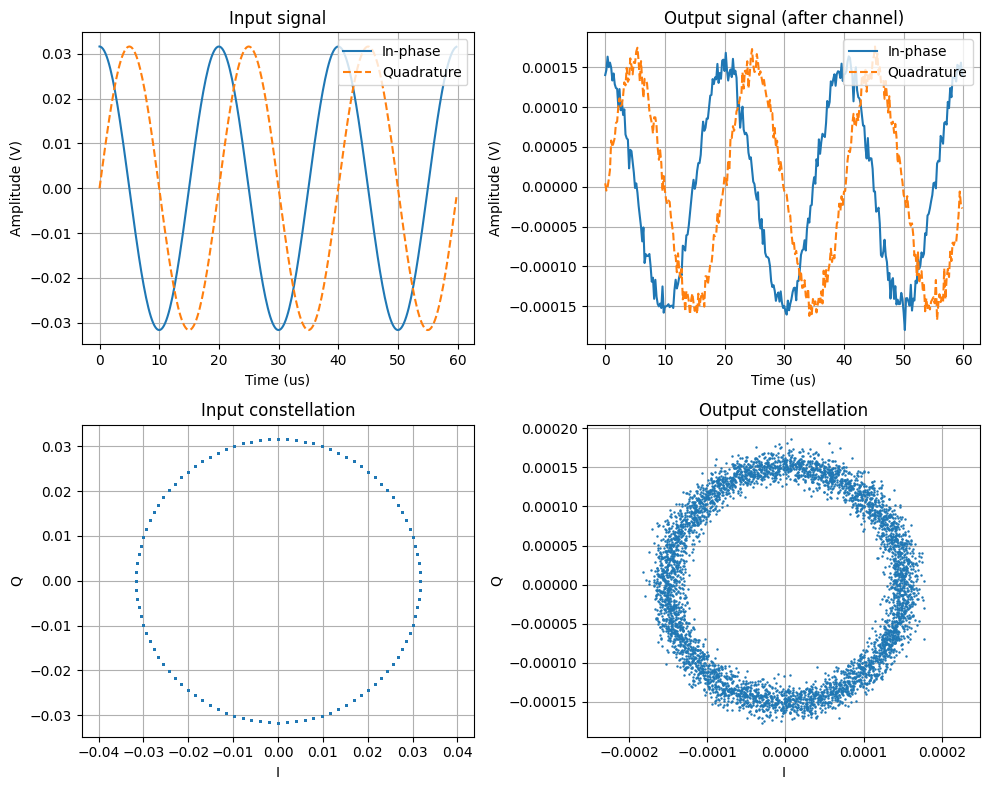

In [7]:
# Visualise the input and output of the channel in both time and IQ.
# Top row : time-domain I and Q over a few tone periods.
# Bottom  : full constellation cloud.

n_periods = 3
nplot     = int(np.ceil(n_periods * fs / f0))
t_us      = np.arange(nplot) / fs * 1e6

n_const = 5000

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# --- Time domain ---
for ax, sig, title in [
    (axes[0, 0], sig_in,  "Input signal"),
    (axes[0, 1], sig_out, "Output signal (after channel)"),
]:
    ax.plot(t_us, np.real(sig.x[:nplot]),        label="In-phase")
    ax.plot(t_us, np.imag(sig.x[:nplot]), '--',  label="Quadrature")
    ax.set_xlabel("Time (us)")
    ax.set_ylabel("Amplitude (V)")
    ax.set_title(title)
    ax.grid(True)
    ax.legend(loc='upper right')

# --- Constellation ---
for ax, sig, title in [
    (axes[1, 0], sig_in,  "Input constellation"),
    (axes[1, 1], sig_out, "Output constellation"),
]:
    ax.plot(np.real(sig.x[:n_const]), np.imag(sig.x[:n_const]),
            '.', markersize=1.5)
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True)

plt.tight_layout()
plt.show()